## GET the data
all in ./data directory

### -----> Luise
just copy the INPDB 

```bash
$ cp -L /home/papa/Documents/explore_inp/inpdb_coloc/data/inp_db/20260417_Immersion_2003_2020_INPDB.csv ./data/inp_db/
```

and create symlinks to the data files in the HPC in the correct locations:

```bash
$ ln -s /home/papa/data/aerosol_cams_climatology_49r2_1951-2019_4D.nc ./data/cams_clim
$ ln -s /hpcperm/papa/inp_db_coloc/cams_free/*_sites_zarr ./data/cams_free
```

### -----> Cuiqi
The locations are the same, but I will just make a tarball to ship via magic wormhole (https://pypi.org/project/magic-wormhole/).
```bash
$ cd < to somewhere with more than 50GB of free space >
$ pip install magic-wormhole
$ wormhole receive < secret_code >
$ tar -xvf cuiqi_temp_data.tar.gz
```
and move the content into the corresponding directories in ./data


## Re-organise the CSV INP DB into a class
we want something that can be used to quickly obtain the aerosols (from climatology or other datasets) at the same locations and times with some flexibilities:
* for a given set of locations, obtain aerosols for an arbitrary time range
* for a given region, extract all locations
* for a given time range, extract all locations (not yet implemented)

and so on

### Working directory
Make sure you are in the correct directory, otherwise ./data or the modules won't be found. If you are running via jupyter-lab server, you can either cd into the correct directory or manually set with `os.chdir()` from within the notebook.
```pythonimport os
os.chdir('/path/to/your/directory')
```

In [2]:
! head ./data/inp_db/20260417_Immersion_2003_2020_INPDB.csv

Year,Month,Day,Time,Season,T [K],RHw [%],RHi [%],IN [L-1],Instrument,Instrument_Type,Reference [author  year],DOI,Campaign,Loc,Platform,Lat,Lon,Alt [m],Location,Region,City,Country,Country_Code,Continent,Continent_IPCC,Type_IPCC,Name_IPCC,RHihomo,Homo_flag,FrezMode,Instrument_Mode
2015,3.0,6.0,10:52:00,MAM,243.15,104.0,140.0,5.9,HINC,DynamicChamber_ContinuousFlowDiffusionChamber,Ansmann et al. 2019,https://doi.org/10.5194/acp-19-15087-2019,,surface,Ground,35.04,33.06,530.0,Cyprus,N. Mid-lat.,Nicosia,Cyprus,CY,Europe,EUROPE-AFRICA,Land-Ocean,Mediterranean,,,Immersion,online
2015,3.0,7.0,13:07:00,MAM,243.15,104.0,140.0,2.58,HINC,DynamicChamber_ContinuousFlowDiffusionChamber,Ansmann et al. 2019,https://doi.org/10.5194/acp-19-15087-2019,,surface,Ground,35.04,33.06,530.0,Cyprus,N. Mid-lat.,Nicosia,Cyprus,CY,Europe,EUROPE-AFRICA,Land-Ocean,Mediterranean,,,Immersion,online
2015,3.0,7.0,13:37:00,MAM,243.15,104.0,140.0,3.97,HINC,DynamicChamber_ContinuousFlowDiffusionChamber,Ansmann et al. 2019,

## Load into collection
inp_coll stores now the content of the CSV data
cdo must be available in the current environment. If cdo is loaded as a module, do so before starting the jupyter-lab server
```bash
$ module load cdo
$ cd < to the directory of this notebook > (optional)
$ jupyter-lab < your options >
```

# Examples for using the collection API
Sorry there is nothing really documented, but I hope these examples show the available usage scenarios. Different access modes and functionalities we can implement later on. For now the model data are extracted just from the lowest available pressure level, so correct for surface. I will implement also the vertical colocation in June, but if urgent let's discuss this.

In [1]:
# There is a main class taking care of aligning and manage consistently obs and model data. It can be expanded also to include other model data, e.g. merra2 if we want (have a look at ./src/structs)

import numpy as np
import xarray as xr

from src.main import build_collection
inp_coll = build_collection()

Using default value for cams_free_file: *_zarr
Using default value for cams_clim_file: aerosol_cams_climatology_49r2_1951-2019_4D.nc
Using default value for inpdb_csvfile: 20260417_Immersion_2003_2020_INPDB.csv
Using default value for lonlat_approx: 0.1
Using default value for t_approx_h: True
Successfully read configuration from None
Loading INP collection from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/inp_db/20260417_Immersion_2003_2020_INPDB.csv


/etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/src/structs/collector.py:125: DtypeWarning: Columns (4,10,13,14,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, nrows=n_lines)


Loading CAMS climatology from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/cams_clim/aerosol_cams_climatology_49r2_1951-2019_4D_sites.nc
Loading CAMS free output from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/cams_free/*_zarr
Opening archives as zarr
Getting surface fields
Getting pl fields


In [2]:
#co-located climatology aerosols for all entries
inp_coll.get_cams_clim()


<xarray.Dataset> Size: 17MB
Dimensions:            (time: 213391)
Coordinates:
    lon                (time) float64 2MB 33.1 33.1 33.1 ... 164.1 164.1 164.1
    lat                (time) float64 2MB 35.0 35.0 35.0 ... -74.7 -74.7 -74.7
    lev                int16 2B 21
  * time               (time) datetime64[ns] 2MB 2015-03-06T10:00:00 ... 2011...
    col                (time) int64 2MB 132 132 132 132 132 ... 377 377 377 377
Data variables:
    Mineral_Dust_bin1  (time) float64 2MB 3.684e-10 3.659e-10 ... 4.373e-16
    Mineral_Dust_bin2  (time) float64 2MB 3.439e-09 3.415e-09 ... 4.207e-15
    Mineral_Dust_bin3  (time) float64 2MB 3.712e-08 3.701e-08 ... 3.826e-14
    Sea_Salt_bin1      (time) float64 2MB 1.572e-09 1.589e-09 ... 7.539e-11
    Sea_Salt_bin2      (time) float64 2MB 3.043e-08 3.047e-08 ... 9.876e-10
    Sea_Salt_bin3      (time) float64 2MB 1.969e-08 1.97e-08 ... 8.546e-10

In [3]:
#co-located cams free aerosols for all entries (lazy loaded! to get the actual data, consider read time from disk)
inp_coll.get_cams_free()

<xarray.Dataset> Size: 12MB
Dimensions:            (time: 213391)
Coordinates:
  * time               (time) datetime64[ns] 2MB 2015-03-06T09:00:00 ... 2011...
    lat                (time) float64 2MB 35.0 35.0 35.0 ... -74.7 -74.7 -74.7
    lon                (time) float64 2MB 33.1 33.1 33.1 ... 164.1 164.1 164.1
    plev               float64 8B 1e+05
Data variables:
    z                  (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    Sea_Salt_bin1      (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    Sea_Salt_bin2      (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    Sea_Salt_bin3      (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    Mineral_Dust_bin1  (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    Mineral_Dust_bin2  (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    Mineral_Dust_bin3  (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
    t                  (time) float32 854kB dask.array<chunksize=(213391,), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Mon May 04 02:02:10 2026: cdo --eccodes -f nc4 -remapbil,./...
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...

In [4]:
# All INP concentrations entries
inp_coll.INP_conc.values

array([5.9       , 2.58      , 3.97      , ..., 0.01780732, 0.02993569,
       0.02472472], shape=(213391,))

In [5]:
# Get as Dataset
inp_coll.to_xarray()

<xarray.Dataset> Size: 9MB
Dimensions:   (time: 213391)
Coordinates:
  * time      (time) datetime64[ns] 2MB 2015-03-06T10:00:00 ... 2011-11-14T22...
    lon       (time) float32 854kB 33.1 33.1 33.1 33.1 ... 164.1 164.1 164.1
    lat       (time) float32 854kB 35.0 35.0 35.0 35.0 ... -74.7 -74.7 -74.7
    alt       (time) float32 854kB 530.0 530.0 530.0 530.0 ... 0.0 0.0 0.0 0.0
Data variables:
    T         (time) float32 854kB 243.1 243.1 243.1 243.1 ... 256.1 256.1 256.1
    RHw       (time) float32 854kB 104.0 104.0 104.0 104.0 ... 100.2 100.2 100.2
    RHi       (time) float32 854kB 140.0 140.0 140.0 140.0 ... 120.0 120.0 120.0
    INP_conc  (time) float64 2MB 5.9 2.58 3.97 2.01 ... 0.01781 0.02994 0.02472

Clim lons are correct: True
Clim lats are correct: True
Free lons are correct: True
Free lats are correct: True


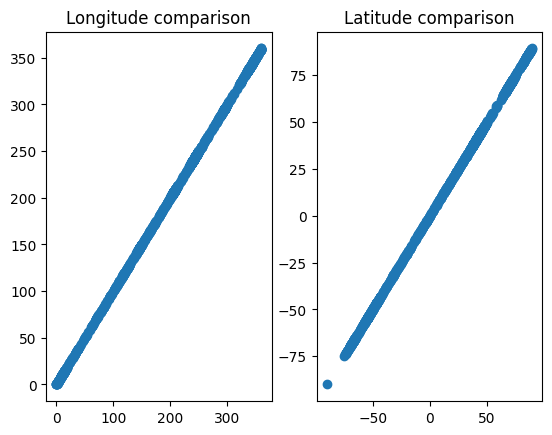

In [6]:
# Just to double-check that the coordinates between INPDB and model data are aligned
import matplotlib.pyplot as plt
fig, axs = plt.subplots(ncols=2)
ax1, ax2 = axs
ax1.scatter(inp_coll.sparse.coord_lons, inp_coll.cams_clim.data.lon.values)
ax2.scatter(inp_coll.sparse.coord_lats, inp_coll.cams_clim.data.lat.values)
ax1.set_title("Longitude comparison")
ax2.set_title("Latitude comparison")
print(f"Clim lons are correct: {np.isclose(inp_coll.sparse.coord_lons, inp_coll.cams_clim.data.lon.values).max()}")
print(f"Clim lats are correct: {np.isclose(inp_coll.sparse.coord_lats, inp_coll.cams_clim.data.lat.values).max()}")
print(f"Free lons are correct: {np.isclose(inp_coll.sparse.coord_lons, inp_coll.cams_free.data.lon.values).max()}")
print(f"Free lats are correct: {np.isclose(inp_coll.sparse.coord_lats, inp_coll.cams_free.data.lat.values).max()}")

For a square region, get all locations and exactly co-located aerosols from climatology

In [7]:
ini_date = "2018-01-01"
end_date = "2018-12-31"

inp_tsub = inp_coll.get_timerange_subset(ini_date, end_date)

(array([ 370., 2001., 6500.,  434.,  632.,  137., 1249.,  196.,  169.,
        1463.]),
 array([17532.        , 17566.17083333, 17600.34166667, 17634.5125    ,
        17668.68333333, 17702.85416667, 17737.025     , 17771.19583333,
        17805.36666667, 17839.5375    , 17873.70833333]),
 <BarContainer object of 10 artists>)

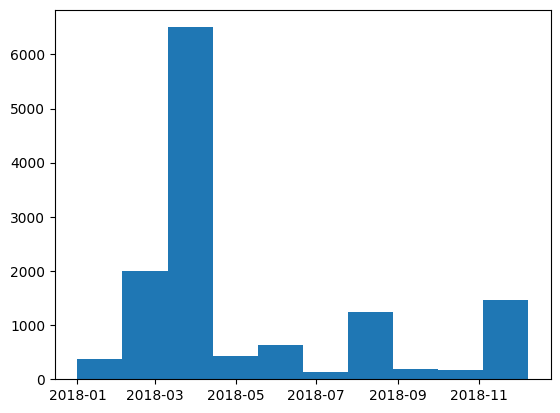

In [8]:
plt.hist(inp_tsub.time())

In [9]:
print(f"Clim lons are correct: {np.isclose(inp_tsub.sparse.coord_lons, inp_tsub.cams_clim.data.lon.values).max()}")
print(f"Clim lats are correct: {np.isclose(inp_tsub.sparse.coord_lats, inp_tsub.cams_clim.data.lat.values).max()}")
print(f"Free lons are correct: {np.isclose(inp_tsub.sparse.coord_lons, inp_tsub.cams_free.data.lon.values).max()}")
print(f"Free lats are correct: {np.isclose(inp_tsub.sparse.coord_lats, inp_tsub.cams_free.data.lat.values).max()}")

Clim lons are correct: True
Clim lats are correct: True
Free lons are correct: True
Free lats are correct: True


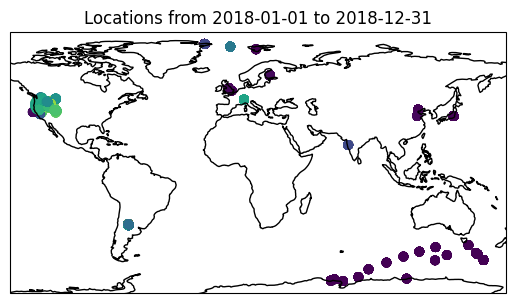

In [10]:
from cartopy import crs as ccrs
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_title(f"Locations from {ini_date} to {end_date}")
ax.scatter(inp_tsub.lon(), inp_tsub.lat(), c=inp_tsub.alt(),
            transform=ccrs.PlateCarree())

In [11]:
# Access by location
lonw, lone = 50, 170
lats, latn = -90, -40
inp_subs = inp_tsub.get_region_subset(lon_west=lonw, lon_east=lone,
                                      lat_south=lats, lat_north=latn,
                                      regenerate_coord_index=True
                                      )
sub_times = xr.DataArray(data=inp_subs.time(),
                         dims=["time"],
                         coords={"time": inp_subs.time()})

print(f"Clim lons are correct: {np.isclose(inp_subs.sparse.coord_lons, inp_subs.cams_clim.data.lon.values).max()}")
print(f"Clim lats are correct: {np.isclose(inp_subs.sparse.coord_lats, inp_subs.cams_clim.data.lat.values).max()}")
print(f"Free lons are correct: {np.isclose(inp_subs.sparse.coord_lons, inp_subs.cams_free.data.lon.values).max()}")
print(f"Free lats are correct: {np.isclose(inp_subs.sparse.coord_lats, inp_subs.cams_free.data.lat.values).max()}")

Clim lons are correct: True
Clim lats are correct: True
Free lons are correct: True
Free lats are correct: True


In [12]:
inp_subs.cams_free.data

<xarray.Dataset> Size: 310MB
Dimensions:            (time: 49672, col: 20, plev: 11)
Coordinates:
  * time               (time) datetime64[ns] 397kB 2003-01-01T03:00:00 ... 20...
    lat                (col) float64 160B -67.6 -67.5 -67.5 ... -54.6 -54.5
    lon                (col) float64 160B 62.8 62.8 62.9 ... 155.2 158.9 158.9
  * plev               (plev) float64 88B 1e+04 1.5e+04 2e+04 ... 9.25e+04 1e+05
Dimensions without coordinates: col
Data variables:
    z                  (time, col) float32 4MB dask.array<chunksize=(2921, 20), meta=np.ndarray>
    Sea_Salt_bin1      (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
    Sea_Salt_bin2      (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
    Sea_Salt_bin3      (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
    Mineral_Dust_bin1  (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
    Mineral_Dust_bin2  (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
    Mineral_Dust_bin3  (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
    t                  (time, plev, col) float32 44MB dask.array<chunksize=(1460, 11, 20), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Mon May 04 02:02:10 2026: cdo --eccodes -f nc4 -remapbil,./...
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...

Text(0, 0.5, 'Latitude')

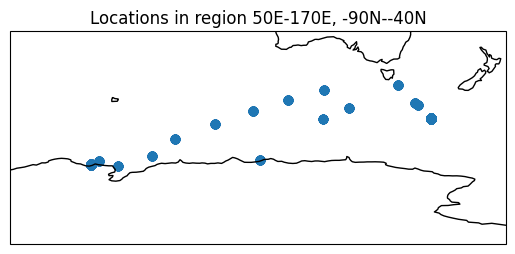

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_extent([lonw-10, lone+10, lats-10, latn+10],
              crs=ccrs.PlateCarree())
ax.set_title(f"Locations in region {lonw}E-{lone}E, {lats}N-{latn}N")
ax.scatter(inp_subs.lon(), inp_subs.lat(), transform=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [14]:
# Let's request all data for those dates across all locations (explode mode)
# Max temporal information from the model data
var = "Mineral_Dust_bin3"

# 3-hourly data throughout the covered obs period for prognostics
timerange_3h = np.arange(inp_subs.time().min(), inp_subs.time().max(), np.timedelta64(3, 'h'), dtype='datetime64')
# Daily data for the same period for climatology
timerange_d= np.arange(inp_subs.time().min(), inp_subs.time().max(), np.timedelta64(3, 'h'), dtype='datetime64')

this_free_stats = inp_subs.get_cams_free(time=timerange_3h, var_subset=var).quantile([p1,0.5,p2], dim="col")
this_clim_stats = inp_subs.get_cams_clim(time=timerange_d, var_subset=var).quantile([p1,0.5,p2], dim="col")

NameError: name 'p1' is not defined

NameError: name 'this_free_stats' is not defined

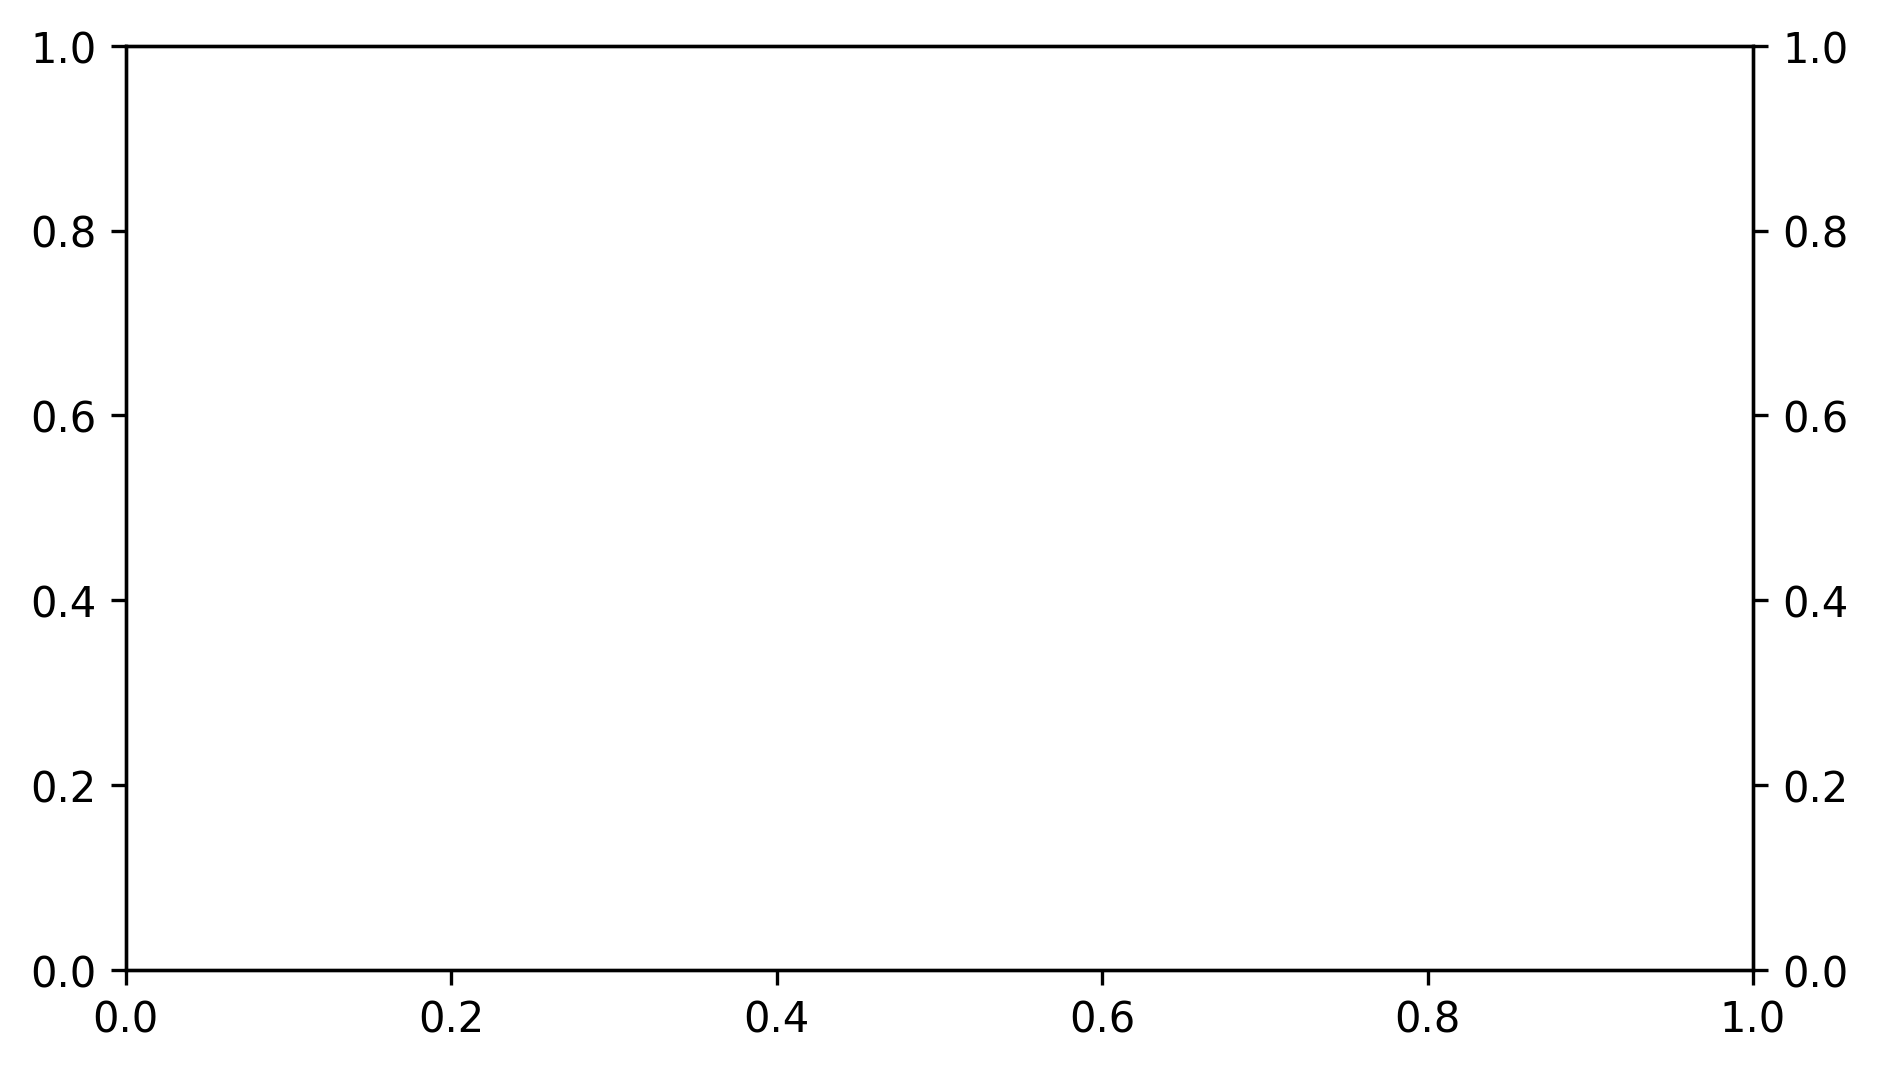

In [15]:
p1,p2 = 0.25, 0.75
fig, ax = plt.subplots(dpi=300, figsize=(7,4))
ax2 = ax.twinx()

# Free run, prognostic aerosols
ax.plot(this_free_stats.time, this_free_stats.sel(quantile=0.5), label="CAMS Free")
ax.fill_between(this_free_stats.time, this_free_stats.sel(quantile=p1), this_free_stats.sel(quantile=p2), alpha=0.3, label=f"{p1*100:.0f}-{p2*100:.0f}th region ptile")
# Climatology
ax.plot(this_clim_stats.time, this_clim_stats.sel(quantile=0.5), label="CAMS Clim")
ax.fill_between(this_clim_stats.time, this_clim_stats.sel(quantile=p1), this_clim_stats.sel(quantile=p2), alpha=0.1, label=f"{p1*100:.0f}-{p2*100:.0f}th region ptile")
ax.legend()
ax.set_ylabel(f"{var.replace('_', ' ')} MMR [Kg/Kg]")

t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)
sc = ax2.scatter(inp_subs.time(), inp_subs.INP_conc.values,
            c=inp_subs.T(), label="INP obs", edgecolor='k', alpha=0.7,
            cmap=cmap, norm=norm)
ax2.set_ylabel("INP concentration [$\mathrm{L^{-1}}$]")
cbar = fig.colorbar(sc, ax=ax2, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.15)
# rotate date labels
ax.xaxis.set_tick_params(rotation=45)

Text(0.5, 0.99, 'Mineral Dust bin3 from model vs INP colocated')

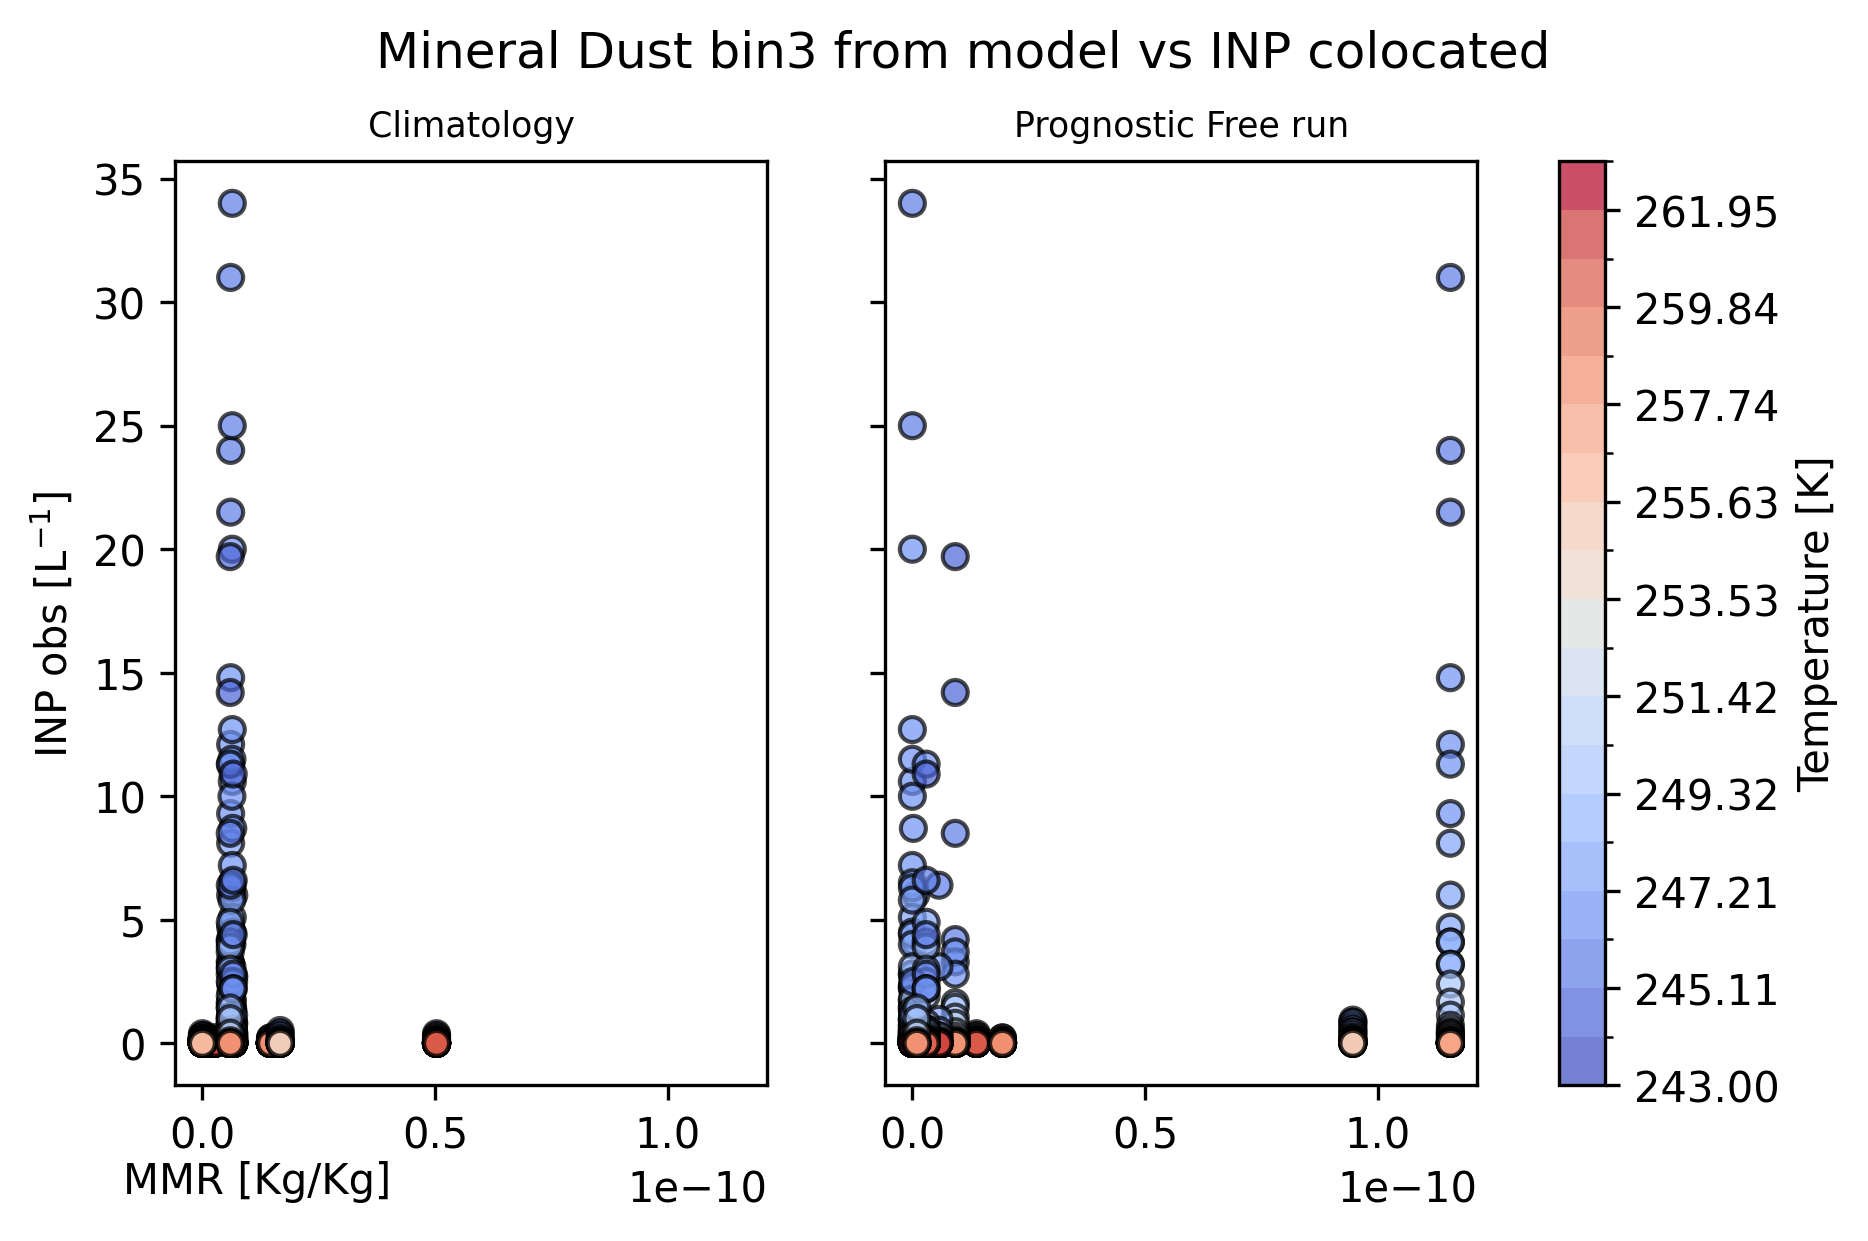

In [16]:
# Co-located data (time and space)

fig, axs = plt.subplots(ncols=2, dpi=300, figsize=(7,4),
                        sharey=True, sharex=True)
var = "Mineral_Dust_bin3"

ax1, ax2 = axs

t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)

sc = ax1.scatter(inp_subs.get_cams_clim(var_subset=var).values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = ax2.scatter(inp_subs.get_cams_free(var_subset=var).values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
cbar = fig.colorbar(sc, ax=axs, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.05)
fig.text(x=0.1, y=0.02, s=f"MMR [Kg/Kg]", ha="left")
ax1.set_ylabel("INP obs [$\mathrm{L^{-1}}$]")
ax1.set_title("Climatology", size="small")
ax2.set_title("Prognostic Free run", size="small")

fig.suptitle(f"{var.replace('_',' ')} from model vs INP colocated", y=0.99)